# AI-Powered Workforce Analytics & Talent Intelligence Dashboard

## Data Understanding

### Objective

This notebook performs the initial assessment of the workforce dataset to understand its structure, data quality, feature distributions, target variable, and suitability for workforce analytics and attrition prediction.

The analysis will establish the foundation for subsequent data engineering, analytics, machine learning, and AI components of the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
data_path = "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(data_path)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 35)

In [4]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


In [8]:
data_dictionary = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isnull().sum().values,
    "unique_values": df.nunique().values
})

data_dictionary

,column,data_type,missing_values,unique_values
Age,Age,int64,0,43
Attrition,Attrition,object,0,2
BusinessTravel,BusinessTravel,object,0,3
DailyRate,DailyRate,int64,0,886
Department,Department,object,0,3
DistanceFromHome,DistanceFromHome,int64,0,29
Education,Education,int64,0,5
EducationField,EducationField,object,0,6
EmployeeCount,EmployeeCount,int64,0,1
EmployeeNumber,EmployeeNumber,int64,0,1470


In [9]:
data_dictionary.to_csv(
    "../reports/data_dictionary.csv",
    index=False
)

In [10]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

### Missing Value Assessment

The dataset contains no missing values across the 35 available attributes. Therefore, no missing-value imputation is required at the initial data-cleaning stage.

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique()[:20])


Age
[41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42]

Attrition
['Yes' 'No']

BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

DailyRate
[1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371]

Department
['Sales' 'Research & Development' 'Human Resources']

DistanceFromHome
[ 1  8  2  3 24 23 27 16 15 26 19 21  5 11  9  7  6 10  4 25]

Education
[2 1 4 3 5]

EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

EmployeeCount
[1]

EmployeeNumber
[ 1  2  4  5  7  8 10 11 12 13 14 15 16 18 19 20 21 22 23 24]

EnvironmentSatisfaction
[2 3 4 1]

Gender
['Female' 'Male']

HourlyRate
[94 61 92 56 40 79 81 67 44 84 49 31 93 50 51 80 96 78 45 82]

JobInvolvement
[3 2 4 1]

JobLevel
[2 1 3 4 5]

JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Directo

In [13]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Attrition ---
Attrition
No     1233
Yes     237
Name: count, dtype: int64

--- BusinessTravel ---
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

--- Department ---
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

--- EducationField ---
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

--- Gender ---
Gender
Male      882
Female    588
Name: count, dtype: int64

--- JobRole ---
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int

In [14]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [15]:
attrition_distribution = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

attrition_distribution

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

## Feature Categorization

The available variables are grouped according to their potential business and analytical role.

In [16]:
demographic_features = [
    "Age",
    "Gender",
    "MaritalStatus",
    "Education",
    "EducationField"
]

organizational_features = [
    "Department",
    "JobRole",
    "JobLevel",
    "BusinessTravel"
]

compensation_features = [
    "DailyRate",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "PercentSalaryHike",
    "StockOptionLevel"
]

engagement_features = [
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance"
]

career_features = [
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "NumCompaniesWorked"
]

performance_learning_features = [
    "PerformanceRating",
    "TrainingTimesLastYear"
]

work_condition_features = [
    "OverTime",
    "DistanceFromHome"
]

In [17]:
administrative_columns = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df[administrative_columns].nunique()

EmployeeCount        1
EmployeeNumber    1470
Over18               1
StandardHours        1
dtype: int64

In [18]:
for column in administrative_columns:
    print(column, df[column].unique())

EmployeeCount [1]
EmployeeNumber [   1    2    4 ... 2064 2065 2068]
Over18 ['Y']
StandardHours [80]


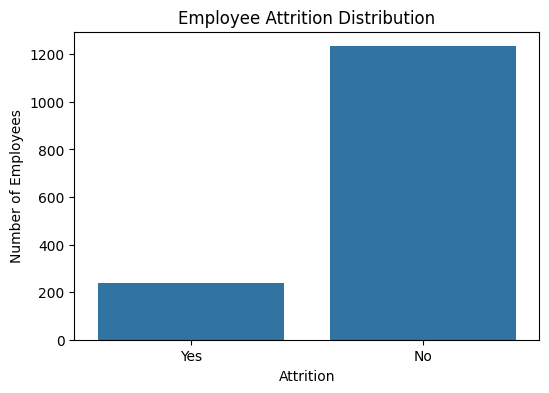

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

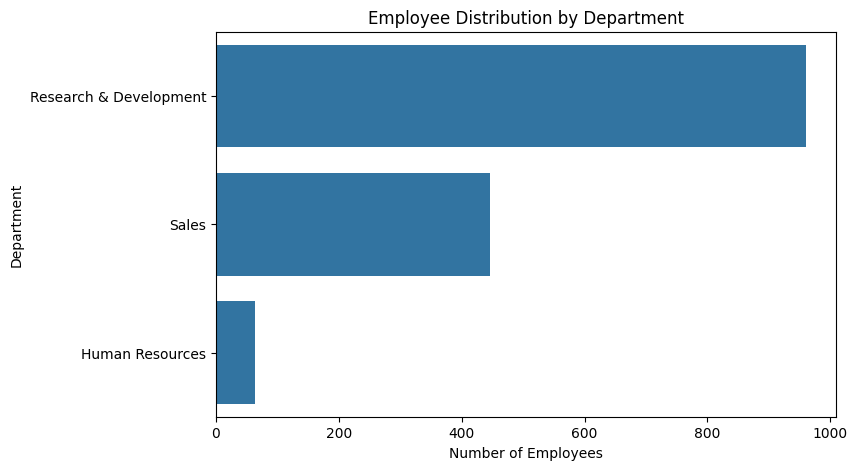

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    y="Department",
    order=df["Department"].value_counts().index
)

plt.title("Employee Distribution by Department")
plt.xlabel("Number of Employees")
plt.ylabel("Department")

plt.show()

## Initial Business Questions

The project will investigate the following workforce intelligence questions:

1. What workforce characteristics are associated with employee attrition?
2. Which departments and job roles show higher attrition?
3. How are overtime and work-life balance related to attrition?
4. How do job satisfaction and workplace satisfaction relate to employee retention?
5. Does compensation appear to differ between employees who leave and those who remain?
6. How do career progression and tenure relate to attrition?
7. What employee groups may require proactive retention attention?
8. What workforce characteristics can support talent development and skill-gap analysis?
9. Which workforce indicators can be combined into an organizational health score?
10. Can machine learning provide useful attrition-risk predictions beyond descriptive analytics?